In [ ]:
! pip install opendatasets

In [1]:
print("hii")

hii


In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/bryanbradfo/gsoc-deeplense-lens-finding")

In [2]:
import os

base_path = "/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding"

print("Level 1 folders:")
print(os.listdir(base_path))


Level 1 folders:
['train_lenses', 'test_nonlenses', 'train_nonlenses', 'test_lenses']


In [3]:
import os

# Define paths
data_dir = "/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding"

# Define the actual directories found
train_lenses_dir = os.path.join(data_dir, 'train_lenses')
train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_lenses_dir = os.path.join(data_dir, 'test_lenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def count_files(directory):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return 0
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

# Calculate total counts for 'substructure' (lenses) and 'no substructure' (non-lenses)
total_substructure_count = count_files(train_lenses_dir) + count_files(test_lenses_dir)
total_no_substructure_count = count_files(train_nonlenses_dir) + count_files(test_nonlenses_dir)

print(f" Substructure Images (total lenses): {total_substructure_count}")
print(f" No Substructure Images (total non-lenses): {total_no_substructure_count}")


 Substructure Images (total lenses): 1925
 No Substructure Images (total non-lenses): 48130


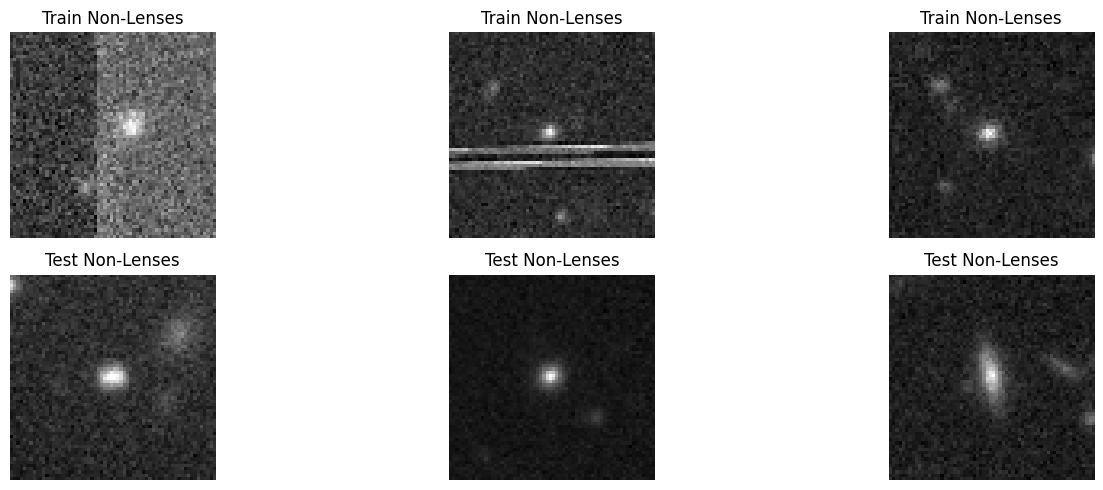

In [4]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

# Define paths (from previous execution)
data_dir = '/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding'

train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def get_sample_images(directory, num_samples=3):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return []
    all_files = [os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    return random.sample(all_files, min(num_samples, len(all_files)))

# Get sample images from each category for non-lenses
sample_train_nonlenses = get_sample_images(train_nonlenses_dir)
sample_test_nonlenses = get_sample_images(test_nonlenses_dir)

# Only include 'non-lenses' categories for display
all_samples = {
    'Train Non-Lenses': sample_train_nonlenses,
    'Test Non-Lenses': sample_test_nonlenses
}

plt.figure(figsize=(15, 5)) # Adjust figure size for fewer categories
plot_index = 1

for category, paths in all_samples.items():
    for img_path in paths:
        if os.path.exists(img_path):
            plt.subplot(len(all_samples), len(paths), plot_index)
            try:
                img_array = np.load(img_path)
                # Transpose the array from (channels, height, width) to (height, width, channels)
                if img_array.shape[0] == 3 and len(img_array.shape) == 3: # Check if it's (3, H, W)
                    img_array = np.transpose(img_array, (1, 2, 0)) # Change to (H, W, 3)

                # If it's still 3 channels but needs to be displayed as grayscale, take the mean across channels
                if img_array.shape[-1] == 3 and len(img_array.shape) == 3:
                    img_array = img_array.mean(axis=-1) # Take mean across channels for grayscale display

                plt.imshow(img_array, cmap='gray') # Display the numpy array, assuming grayscale
                plt.title(f"{category}")
                plt.axis('off')
                plot_index += 1
            except Exception as e:
                print(f"Error loading or displaying {img_path}: {e}")
        else:
            print(f"Could not find image: {img_path}")

plt.tight_layout()
plt.show()


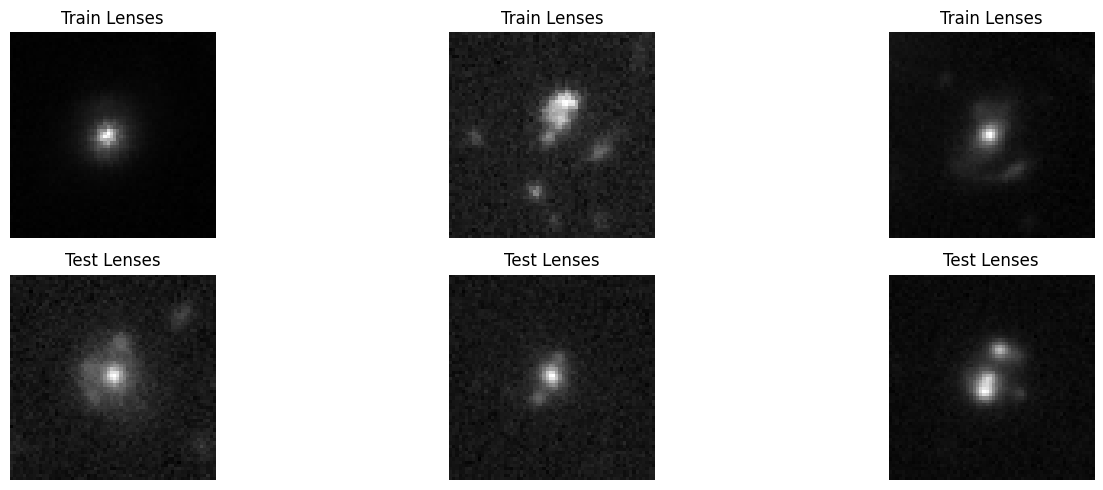

In [5]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np # Import numpy to handle .npy files

# Define paths (from previous execution)
data_dir = '/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding'

train_lenses_dir = os.path.join(data_dir, 'train_lenses')
train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_lenses_dir = os.path.join(data_dir, 'test_lenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def get_sample_images(directory, num_samples=3):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return []
    all_files = [os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    return random.sample(all_files, min(num_samples, len(all_files)))

# Get sample images from each category
sample_train_lenses = get_sample_images(train_lenses_dir)
sample_test_lenses = get_sample_images(test_lenses_dir)

# Only include 'lenses' categories for display
all_samples = {
    'Train Lenses': sample_train_lenses,
    'Test Lenses': sample_test_lenses
}

plt.figure(figsize=(15, 5)) # Adjust figure size for fewer categories
plot_index = 1

for category, paths in all_samples.items():
    for img_path in paths:
        if os.path.exists(img_path):
            plt.subplot(len(all_samples), len(paths), plot_index)
            try:
                img_array = np.load(img_path)
                # Transpose the array from (channels, height, width) to (height, width, channels)
                if img_array.shape[0] == 3 and len(img_array.shape) == 3: # Check if it's (3, H, W)
                    img_array = np.transpose(img_array, (1, 2, 0)) # Change to (H, W, 3)

                # If it's still 3 channels but needs to be displayed as grayscale, take the mean across channels
                if img_array.shape[-1] == 3 and len(img_array.shape) == 3:
                    img_array = img_array.mean(axis=-1) # Take mean across channels for grayscale display

                plt.imshow(img_array, cmap='gray') # Display the numpy array, assuming grayscale
                plt.title(f"{category}")
                plt.axis('off')
                plot_index += 1
            except Exception as e:
                print(f"Error loading or displaying {img_path}: {e}")
        else:
            print(f"Could not find image: {img_path}")

plt.tight_layout()
plt.show()


In [6]:
lenses_paths = []
for directory in [train_lenses_dir, test_lenses_dir]:
    if os.path.isdir(directory):
        lenses_paths.extend([os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    else:
        print(f"Warning: Directory not found: {directory}")

non_lenses_paths = []
for directory in [train_nonlenses_dir, test_nonlenses_dir]:
    if os.path.isdir(directory):
        non_lenses_paths.extend([os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    else:
        print(f"Warning: Directory not found: {directory}")

print(f"Total lenses images found: {len(lenses_paths)}")
print(f"Total non-lenses images found: {len(non_lenses_paths)}")

Total lenses images found: 1925
Total non-lenses images found: 48130


In [7]:
all_paths = lenses_paths + non_lenses_paths
all_labels = [1] * len(lenses_paths) + [0] * len(non_lenses_paths)

print(f"Total images in combined dataset: {len(all_paths)}")
print(f"Total lenses images in combined dataset: {sum(all_labels)}")
print(f"Total non-lenses images in combined dataset: {len(all_labels) - sum(all_labels)}")

Total images in combined dataset: 50055
Total lenses images in combined dataset: 1925
Total non-lenses images in combined dataset: 48130


In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

print(f"Training set - Lenses: {sum(y_train)}, Non-lenses: {len(y_train) - sum(y_train)}")
print(f"Validation set - Lenses: {sum(y_val)}, Non-lenses: {len(y_val) - sum(y_val)}")


Training set - Lenses: 1540, Non-lenses: 38504
Validation set - Lenses: 385, Non-lenses: 9626


***PARAMETERS***

In [9]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import random
import os

2026-02-24 09:13:20.858338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771924401.236292      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771924401.321923      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771924402.160161      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771924402.160208      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771924402.160211      55 computation_placer.cc:177] computation placer alr

In [10]:
#setting the seed
SEED = 42
keras.utils.set_random_seed(SEED)

#hyperparameters
BUFFER_SIZE = 1224 # how many imgs are we shuffling at once
BATCH_SIZE = 256 # how many imgs are we loading at once
AUTO = tf.data.AUTOTUNE # how many threads to use for prefetching
INPUT_SHAPE = (32,32,3)
NUM_CLASS = 100

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.001 #Penalty to prevent overfitting (memorizing instead of learning)
EPOCHS = 250
IMAGE_SIZE = 48
PATCH_SIZE = 4
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
MASK_PROPORTION = 0.90

ENC_PROJ_DIM = 192 #PROJECTION_DIM = How many numbers represent each patch
DEC_PROJ_DIM = 96 #Decoder uses 96 (was 64, changed to match definition in decoder cell)
ENC_NUM_HEADS = 8 #NUM_HEADS = Attention heads (AI looks at image in 4 different ways simultaneously)
ENC_LAYERS = 10 #LAYERS = Stack 6 transformer blocks on top of each other (deeper = more learning)
LAYER_NORM_EPS = 1e-6
DEC_NUM_HEADS = 4
DEC_LAYERS = 6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]

DEC_TRANSFORMER_UNITS = [
    DEC_PROJ_DIM * 4,
    DEC_PROJ_DIM,
]

PATCH_AREA = PATCH_SIZE * PATCH_SIZE * 3 # Calculate once, globally

In [11]:
# FIXED PREPROCESSING 

def load_and_preprocess_image(image_path):
    """
    Load .npy file and convert to (48, 48, 3) normalized image
    FIXED for TensorFlow graph mode!
    """
    # Load .npy file
    def load_npy(path):
        img = np.load(path.numpy().decode('utf-8'))
        return img.astype(np.float32)
    
    image = tf.py_function(load_npy, [image_path], tf.float32)
    
    # CRITICAL: Set shape to help TensorFlow
    image.set_shape([None, None, None])
    
    # Get current shape
    current_shape = tf.shape(image)
    ndim = len(image.shape)
    
    # Case 1: 2D image (H, W) -> add channel dimension
    if ndim == 2 or (ndim == 3 and image.shape[-1] is None):
        image = tf.cond(
            tf.equal(tf.size(current_shape), 2),
            lambda: tf.expand_dims(image, axis=-1),
            lambda: image
        )
        current_shape = tf.shape(image)
    
    # Case 2: (C, H, W) -> (H, W, C) - check if first dim is 3
    def maybe_transpose():
        return tf.transpose(image, [1, 2, 0])
    
    def keep_as_is():
        return image
    
    # Only transpose if shape[0] == 3 and shape[1] > 3
    should_transpose = tf.logical_and(
        tf.equal(current_shape[0], 3),
        tf.greater(current_shape[1], 3)
    )
    image = tf.cond(should_transpose, maybe_transpose, keep_as_is)
    
    # Update shape
    current_shape = tf.shape(image)
    
    # Case 3: Grayscale (H, W, 1) -> (H, W, 3)
    def tile_channels():
        return tf.tile(image, [1, 1, 3])
    
    def keep_rgb():
        return image
    
    # Check if last dimension is 1
    is_grayscale = tf.equal(current_shape[-1], 1)
    image = tf.cond(is_grayscale, tile_channels, keep_rgb)
    
    # Resize to target size
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    
    # Normalize to [0, 1]
    image_min = tf.reduce_min(image)
    image_max = tf.reduce_max(image)
    image = (image - image_min) / (image_max - image_min + 1e-8)
    
    # Clip to ensure range
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    # Set final shape explicitly
    image.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])
    
    return image

print(" Fixed preprocessing function loaded!")

 Fixed preprocessing function loaded!


***PATCH LAYER***

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import os


In [13]:
#cutting images into pieces
class Patches(layers.Layer):
  def __init__(self, patch_size = PATCH_SIZE, **kwargs):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.resize = layers.Reshape((-1, patch_size* patch_size * 3))
  # -1 = "figure out this dimension automatically"
# patch_size * patch_size * 3 = 6×6×3 = 108 numbers per patch

  # this func cuts images into non overlapping 6x6 squares
  def call(self, images):
    patches = tf.image.extract_patches(
        images = images,
        sizes = [1, self.patch_size , self.patch_size, 1],#sizes = [batch, height, width, channels] → extract 6×6 patches
        strides = [1, self.patch_size, self.patch_size, 1],#strides = how far to move between patches (6 = no overlap)
        rates = [1, 1, 1, 1],
        padding = "VALID", # means font add extra padding
    )
    patches = self.resize(patches)
    return patches

#this func takes a batch of imgs and helps visualize one image and
# its patches side by side
  def show_patched_image(self, images, patches):
    idx = np.random.choice(patches.shape[0])
    print(f"index selected : {idx}")
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI
    plt.imshow(keras.utils.array_to_img(images[idx]))
    plt.axis("off")
    plt.title("Original Augmented Image")
    plt.show()

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI for the grid
    for i, patch_tensor in enumerate(patches[idx]):
      ax = plt.subplot(n, n, i+1)
      reshaped_patch = tf.reshape(patch_tensor, (self.patch_size, self.patch_size, 3)).numpy()
      ax.imshow(reshaped_patch)
      ax.axis("off")
    plt.suptitle("Individual Patches")
    plt.show()
    return idx

  # this func reconstructs the img by joining the patches
  def reconstruct_from_patch(self,patch):
    num_patches = patch.shape[0]
    n = int(np.sqrt(num_patches))

    #Reshape the flattened patches to their original (patch_size, patch_size, 3) shape
    individual_patches = tf.reshape(patch, (num_patches, self.patch_size, self.patch_size, 3))

    # Arrange the individual patches into an n x n grid
    patches_grid = tf.reshape(individual_patches, (n, n, self.patch_size, self.patch_size, 3))

    # Transpose and reshape to combine patches into a single image
    reconstructed = tf.reshape(
        tf.transpose(patches_grid, perm=[0, 2, 1, 3, 4]),
        [n * self.patch_size, n * self.patch_size, 3]
    )
    return reconstructed

***PATCH ENCODER***

In [14]:
from keras import layers

# Temporarily defining parameters here for execution, should ideally be run from parameter cell
PATCH_SIZE = 4
ENC_PROJ_DIM = 192
MASK_PROPORTION = 0.90

class PatchEncoder(layers.Layer):
  def __init__(
      self,
      patch_size = PATCH_SIZE,
      projection_dim = ENC_PROJ_DIM,
      mask_proportion = MASK_PROPORTION,
      downstream = False,
      **kwargs
  ):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.projection_dim = projection_dim
    self.mask_proportion = mask_proportion
    self.downstream = downstream


    # mask the token now hehehe
    self.mask_token = tf.Variable(
        tf.random.normal([1, patch_size * patch_size * 3]),
        trainable = True,
    ) # this token will learn how the hidden patches look like

  def build(self, input_shape):
    (_, self.num_patches, self.patch_area) = input_shape

    # Create the projection layer for the patches
    self.projection = layers.Dense(units = self.projection_dim)

    # create positional embedding layer
    self.position_embedding = layers.Embedding(
        input_dim = self.num_patches,
        output_dim = self.projection_dim,
    )

    # num of patches itll mask
    self.num_mask = int(self.mask_proportion * self.num_patches)

  def call(self, patches):
    #gets the positional embeddings
    batch_size = tf.shape(patches)[0]
    positions = tf.range(start=0, limit=self.num_patches, delta = 1)
    pos_embeddings = self.position_embedding(positions[tf.newaxis,...])
    pos_embeddings = tf.tile(
        pos_embeddings, [batch_size, 1, 1]
    )

    # embedd the patches
    patch_embeddings = (
        self.projection(patches) + pos_embeddings
    )

    if self.downstream:
      return patch_embeddings

    else:
      mask_indices, unmask_indices = self.get_random_indices(batch_size)
      # selects random patches from batch and mask some and keep some unmasked

      # gathers the unmasked patches that'll be sent into the ENC
      unmasked_embeddings = tf.gather(
          patch_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      #gets the masked and unmasked position embeddings

      unmasked_positions = tf.gather(
          pos_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      mask_positions = tf.gather(
          pos_embeddings,
          mask_indices,
          axis = 1,
          batch_dims = 1,
      )

      mask_tokens = tf.repeat(self.mask_token, repeats = self.num_mask, axis = 0)
      mask_tokens = tf.repeat(
          mask_tokens[tf.newaxis, ...],
          repeats = batch_size,
          axis = 0
      )

      # creats mask embeddings for the masked tokens
      mask_embeddings = self.projection(mask_tokens) + mask_positions
                             # content of the patch + position of the patch
      return(
          unmasked_embeddings, # sent to rnc
          mask_embeddings, # sent to dec
          unmasked_positions, # sent to dec
          mask_indices, #dec
          unmask_indices, # dec
      )

  def get_random_indices(self, batch_size):
        # Create random indices from a uniform distribution and then split
        # it into mask and unmask indices.
        rand_indices = tf.argsort(
            tf.random.uniform(shape=(batch_size, self.num_patches)), axis=-1
        )
        mask_indices = rand_indices[:, : self.num_mask]
        unmask_indices = rand_indices[:, self.num_mask :]
        return mask_indices, unmask_indices

  def generate_masked_image(self, patches, unmask_indices):
        # Choose a random patch and it corresponding unmask index.
        idx = np.random.choice(patches.shape[0])
        patch = patches[idx]
        unmask_index = unmask_indices[idx]

        # Build a numpy array of same shape as patch.
        new_patch = np.zeros_like(patch)

        # Iterate of the new_patch and plug the unmasked patches.
        count = 0
        for i in range(unmask_index.shape[0]):
            new_patch[unmask_index[i]] = patch[unmask_index[i]]
        return new_patch, idx

I0000 00:00:1771924436.528686      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771924436.531480      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


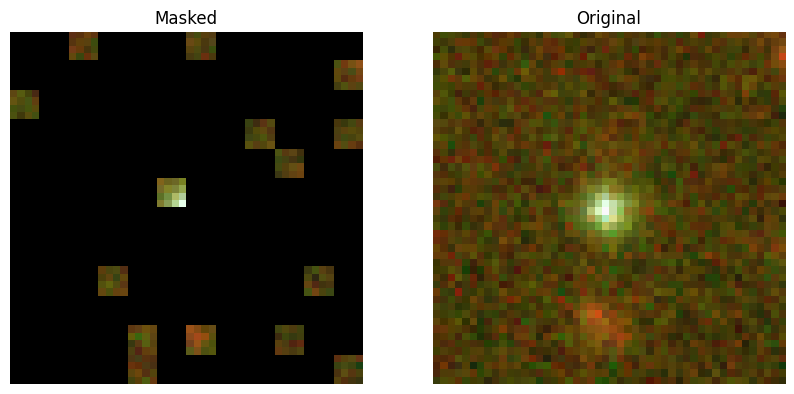

In [15]:
# Create the patch encoder layer.
patch_encoder = PatchEncoder()

# Instantiate Patches layer
patch_layer = Patches(patch_size=PATCH_SIZE)

# Load a sample image
sample_image_path = X_train[0] # Taking one image path from the training set
original_image = np.load(sample_image_path)

# Preprocess the image: Ensure it's (H, W, C) and resize to IMAGE_SIZE
# The original image data might be (C, H, W), so transpose if necessary.
if original_image.shape[0] == 3 and len(original_image.shape) == 3:
    original_image = np.transpose(original_image, (1, 2, 0))

# Convert to tf.float32 for tf.image.resize and normalize if needed.
# Assuming images are already normalized or scaling is handled by tf.image.resize or keras.utils.array_to_img
original_image = tf.image.resize(tf.convert_to_tensor(original_image, dtype=tf.float32), (IMAGE_SIZE, IMAGE_SIZE))

# Ensure 3 channels. If it's grayscale (H, W) or (H, W, 1), convert to (H, W, 3).
if len(original_image.shape) == 2: # (H, W)
    original_image = tf.expand_dims(original_image, axis=-1) # -> (H, W, 1)
    original_image = tf.repeat(original_image, repeats=3, axis=-1) # -> (H, W, 3)
elif original_image.shape[-1] == 1: # (H, W, 1)
    original_image = tf.repeat(original_image, repeats=3, axis=-1) # -> (H, W, 3)

# Add batch dimension: (1, IMAGE_SIZE, IMAGE_SIZE, 3)
augmented_images = tf.expand_dims(original_image, 0)

# Generate patches
patches = patch_layer(augmented_images)


# Get the embeddings and positions.
(
    unmasked_embeddings,
    masked_embeddings,
    unmasked_positions,
    mask_indices,
    unmask_indices,
) = patch_encoder(patches=patches)


# Show a masked patch image.
new_patch, random_index = patch_encoder.generate_masked_image(patches, unmask_indices)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
img = patch_layer.reconstruct_from_patch(new_patch)
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Masked")
plt.subplot(1, 2, 2)
img = augmented_images[random_index]
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Original")
plt.show()

***MLP***

In [16]:
def mlp(x, dropout_rate, hidden_units):
  for units in hidden_units:
    x = layers.Dense(units, activation=tf.nn.gelu)(x)
    x = layers.Dropout(dropout_rate)(x)
  return x

***MAE ENCODER***

In [17]:
import keras
from keras import layers

ENC_PROECTION_DIM = 192
ENC_NUM_HEADS = 6
ENC_LAYERS = 10
DROPOUT_RATE = 0.1
LAYER_NORM_EPS = 1e-6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]


def create_encoder():
  inputs = layers.Input(shape = (None, ENC_PROJ_DIM))
  x = inputs

  for _ in range(ENC_LAYERS):

    # 1. layer norm
    x1 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    # 2, attention
    attention_output = layers.MultiHeadAttention(
        num_heads = ENC_NUM_HEADS,
        key_dim = ENC_PROJ_DIM // ENC_NUM_HEADS,
        dropout = DROPOUT_RATE,
    )(x1, x1)

    attention_output = layers.Dropout(DROPOUT_RATE)(attention_output)

    # 3. residual
    x2 = layers.Add()([x, attention_output])

    # 4. layer norm
    x3 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x2)

    x3 = mlp(x3, hidden_units = ENC_TRANSFORMER_UNITS, dropout_rate = DROPOUT_RATE,)

    x = layers.Add()([x2, x3])

    outputs = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    return keras.Model(inputs, outputs, name = "mae_enc_strong")



In [18]:
optimizer = keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=0.05
)


***DECODER***

In [20]:
import keras
from keras import layers
import tensorflow as tf


# Decoder
def create_decoder():

    inputs = layers.Input((NUM_PATCHES, ENC_PROJ_DIM))

    # Project encoder dim → decoder dim
    x = layers.Dense(DEC_PROJ_DIM)(inputs)

    # Positional embedding for decoder
    positions = tf.range(start=0, limit=NUM_PATCHES, delta=1)
    pos_embedding = layers.Embedding(
        input_dim=NUM_PATCHES,
        output_dim=DEC_PROJ_DIM
    )(positions)

    x = x + pos_embedding

    # Transformer blocks
    for _ in range(DEC_LAYERS):

        # Pre-Norm Attention
        x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

        attn_output = layers.MultiHeadAttention(
            num_heads=DEC_NUM_HEADS,
            key_dim=DEC_PROJ_DIM // DEC_NUM_HEADS,
            dropout=DROPOUT_RATE,
        )(x1, x1)

        attn_output = layers.Dropout(DROPOUT_RATE)(attn_output)

        x2 = layers.Add()([x, attn_output])

        # Pre-Norm MLP
        x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

        x3 = mlp(
            x3,
            hidden_units=DEC_TRANSFORMER_UNITS,
            dropout_rate=DROPOUT_RATE,
        )

        x = layers.Add()([x2, x3])

    x = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

    # Reconstruct patches
    patch_outputs = layers.Dense(PATCH_AREA)(x)

    # Convert patches → image
    outputs = layers.Reshape(
        (IMAGE_SIZE // PATCH_SIZE,
         IMAGE_SIZE // PATCH_SIZE,
         PATCH_SIZE,
         PATCH_SIZE,
         3)
    )(patch_outputs)

    outputs = layers.Lambda(lambda x: tf.transpose(x, perm=[0,1,3,2,4,5]))(outputs)
    outputs = layers.Reshape((IMAGE_SIZE, IMAGE_SIZE, 3))(outputs)

    return keras.Model(inputs, outputs, name="mae_decoder_strong")

***MAE TRAINER***

In [21]:
class MaskedAutoencoder(keras.Model):
    def __init__(
        self,
        train_augmentation_model,
        test_augmentation_model,
        patch_layer,
        patch_encoder,
        encoder,
        decoder,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.train_augmentation_model = train_augmentation_model
        self.test_augmentation_model = test_augmentation_model
        self.patch_layer = patch_layer
        self.patch_encoder = patch_encoder
        self.encoder = encoder
        self.decoder = decoder

    def calculate_loss(self, images, test=False):
        # Augment the input images.
        if test:
            augmented_images = self.test_augmentation_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        # Patch the augmented images.
        patches = self.patch_layer(augmented_images)

        # Encode the patches.
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        # Pass the unmaksed patche to the encoder.
        encoder_outputs = self.encoder(unmasked_embeddings)

        # Create the decoder inputs.
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)

        # Decode the inputs.
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        loss_patch = tf.gather(patches, mask_indices, axis=1, batch_dims=1)
        loss_output = tf.gather(decoder_patches, mask_indices, axis=1, batch_dims=1)

        # Compute the total loss.
        total_loss = self.compute_loss(y=loss_patch, y_pred=loss_output)

        return total_loss, loss_patch, loss_output

    def train_step(self, images):
        with tf.GradientTape() as tape:
            total_loss, loss_patch, loss_output = self.calculate_loss(images)

        # Apply gradients.
        train_vars = [
            self.train_augmentation_model.trainable_variables,
            self.patch_layer.trainable_variables,
            self.patch_encoder.trainable_variables,
            self.encoder.trainable_variables,
            self.decoder.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        tv_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                tv_list.append((g, v))
        self.optimizer.apply_gradients(tv_list)

        # Report progress.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results

    def test_step(self, images):
        total_loss, loss_patch, loss_output = self.calculate_loss(images, test=True)

        # Update the trackers.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results


In [22]:
encoder = create_encoder()

***LOADING WEIGHTS***

In [23]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "mae" in f.lower():
            print(os.path.join(root, f))


/kaggle/input/models/sqyhu80/maecifar100pretrained/tensorflow2/default/1/mae_encoder_cifar100.weights.h5
/kaggle/input/models/sqyhu80/finalpretrainedencoder/tensorflow2/default/1/mae_encoder_pretrained.weights.h5


In [24]:
encoder.load_weights(
    "/kaggle/input/models/sqyhu80/maecifar100pretrained/tensorflow2/default/1/mae_encoder_cifar100.weights.h5"
)

In [25]:
decoder = create_decoder()

In [26]:
# Define simple placeholder augmentation models
train_augmentation_model = tf.keras.Sequential([tf.keras.layers.Identity()])
test_augmentation_model = tf.keras.Sequential([tf.keras.layers.Identity()])

mae_model = MaskedAutoencoder(
    train_augmentation_model=train_augmentation_model,
    test_augmentation_model=test_augmentation_model,
    encoder=encoder,
    decoder=decoder,
    patch_layer=patch_layer,
    patch_encoder=patch_encoder
)

In [27]:
# Function to load and preprocess a single image
def load_and_preprocess_image(image_path):
    # Load the .npy file. The output shape can vary, so we handle it dynamically.
    image = tf.py_function(lambda x: np.load(x.numpy().decode('utf-8')), [image_path], tf.float32)
    # Initially set shape to ensure rank is known for subsequent tf.shape operations
    image.set_shape([None, None, None]) # Assuming max 3 dimensions (H, W, C or C, H, W)

    # Get dynamic shape information
    current_shape = tf.shape(image)
    current_rank = tf.rank(image)

    # --- Handle 2D images: (H, W) -> (H, W, 1) ---
    def expand_to_3d_fn():
        return tf.expand_dims(image, axis=-1)
    image = tf.cond(tf.equal(current_rank, 2), expand_to_3d_fn, lambda: image)

    # Re-evaluate current_shape after potential expansion to 3D
    current_shape = tf.shape(image)

    # --- Handle (C, H, W) -> (H, W, C) transposition if needed ---
    # Heuristic: if the first dimension is 3 and the other two are much larger,
    # it's likely (C, H, W). Otherwise, assume (H, W, C).
    def transpose_chw_to_hwc_fn(): # No 'img' arg needed if 'image' is captured
        return tf.transpose(image, (1, 2, 0))

    # Only transpose if the first dimension is 3 AND the other two are significantly larger than 3,
    # to avoid transposing (H, W, 3) images mistakenly.
    is_chw_format = tf.logical_and(
        tf.equal(current_shape[0], 3),
        tf.logical_and(tf.greater(current_shape[1], 3), tf.greater(current_shape[2], 3))
    )
    image = tf.cond(is_chw_format, transpose_chw_to_hwc_fn, lambda: image)

    # --- Ensure it has 3 channels ---
    # This part MUST happen BEFORE tf.image.resize if resize expects known channels.
    current_channels = tf.shape(image)[-1]

    def convert_1_to_3_channels_fn():
        return tf.repeat(image, repeats=3, axis=2) # Explicit axis=2 for C

    def convert_many_to_3_channels_fn():
        # Reduce to grayscale (1 channel) then repeat to 3 channels
        grayscale_image = tf.reduce_mean(image, axis=2, keepdims=True) # Explicit axis=2 for C
        return tf.repeat(grayscale_image, repeats=3, axis=2) # Explicit axis=2 for C

    image = tf.cond(tf.equal(current_channels, 1),
                    convert_1_to_3_channels_fn,
                    lambda: tf.cond(tf.greater(current_channels, 3),
                                    convert_many_to_3_channels_fn,
                                    lambda: image)) # Assume it's already 3 channels if not 1 or >3

    # Explicitly set static shape with known channel count after channel conversion.
    # This is crucial for tf.image.resize to infer the rank + channels.
    image.set_shape([None, None, 3])

    # Now, `image` should be (H, W, C) with C=3. Resize it.
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    # Explicitly ensure the final output shape for static graph compatibility
    image = tf.ensure_shape(image, (IMAGE_SIZE, IMAGE_SIZE, 3))
    return image

# Create a tf.data.Dataset for validation images
test_ds = (
    tf.data.Dataset.from_tensor_slices(X_val)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Taking a batch of test inputs to measure model's progress.
test_images = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            test_augmented_images = self.model.test_augmentation_model(test_images)
            test_patches = self.model.patch_layer(test_augmented_images)
            (
                test_unmasked_embeddings,
                test_masked_embeddings,
                test_unmasked_positions,
                test_mask_indices,
                test_unmask_indices,
            ) = self.model.patch_encoder(test_patches)
            test_encoder_outputs = self.model.encoder(test_unmasked_embeddings)
            test_encoder_outputs = test_encoder_outputs + test_unmasked_positions
            test_decoder_inputs = tf.concat(
                [test_encoder_outputs, test_masked_embeddings], axis=1
            )
            test_decoder_outputs = self.model.decoder(test_decoder_inputs)

            # Show a maksed patch image.
            test_masked_patch, idx = self.model.patch_encoder.generate_masked_image(
                test_patches, test_unmask_indices
            )
            print(f"\nIdx chosen: {idx}")
            original_image = test_augmented_images[idx]
            masked_image = self.model.patch_layer.reconstruct_from_patch(
                test_masked_patch
            )
            reconstructed_image = test_decoder_outputs[idx]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
            ax[0].imshow(original_image)
            ax[0].set_title(f"Original: {epoch:03d}")

            ax[1].imshow(masked_image)
            ax[1].set_title(f"Masked: {epoch:03d}")

            ax[2].imshow(reconstructed_image)
            ax[2].set_title(f"Resonstructed: {epoch:03d}")

            plt.show()
            plt.close()

In [ ]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        # Warmup
        warmup_lr = self.base_lr * (step / self.warmup_steps)

        # Cosine decay
        cosine_lr = 0.5 * self.base_lr * (
            1 + tf.cos(
                self.pi * (step - self.warmup_steps) /
                (self.total_steps - self.warmup_steps)
            )
        )

        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)


total_steps = int((len(X_train) / BATCH_SIZE) * EPOCHS)
warmup_steps = int(total_steps * 0.25)   # 🔥 25% warmup for 90% masking

lr_schedule = WarmUpCosine(
    base_lr=5e-4,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

In [ ]:
total_steps = int((len(X_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    base_lr=LEARNING_RATE,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

lrs = [scheduled_lrs(step) for step in range(total_steps)]
plt.plot(lrs)
plt.xlabel("Step", fontsize=14)
plt.ylabel("LR", fontsize=14)
plt.show()

# Assemble the callbacks.
train_callbacks = [TrainMonitor(epoch_interval=5)]

In [ ]:
# Check everything matches
print("="*50)
print("ARCHITECTURE CHECK:")
print(f"IMAGE_SIZE: {IMAGE_SIZE}")
print(f"PATCH_SIZE: {PATCH_SIZE}")
print(f"PATCH_AREA: {PATCH_AREA}")
print(f"Expected: {PATCH_SIZE * PATCH_SIZE * 3}")
print()
print("DATA CHECK:")
print(f"DeepLense shape: {deeplense_images.shape}")
print(f"Min/Max: {deeplense_images.min():.3f} / {deeplense_images.max():.3f}")
print(f"Expected: (N, 48, 48, 3) with range [0,1]")
print("="*50)

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

# Create a tf.data.Dataset for training images
train_ds = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# For the validation data, we'll use 'test_ds' that was already defined
val_ds = test_ds # Renaming for clarity if needed, but test_ds serves as validation data

# Compile and pretrain the model.
mae_model.compile(
    optimizer=optimizer, loss=keras.losses.MeanSquaredError(), metrics=["mae"]
)
history = mae_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)

# Measure its performance.
loss, mae = mae_model.evaluate(test_ds)
print(f"Loss: {loss:.2f}")
print(f"MAE: {mae:.2f}")

In [ ]:
encoder.save_weights("/kaggle/working/mae_encoder_pretrained.weights.h5")
print("saved weights")

MAE pretraining was stopped early to avoid overfitting to dominant luminous structures and preserve generalizable representations for downstream physics-informed fine-tuning

***PHASE 3 - FINE TUNING***

In [28]:
encoder.load_weights(
    "/kaggle/input/models/sqyhu80/finalpretrainedencoder/tensorflow2/default/1/mae_encoder_pretrained.weights.h5"
) 

In [29]:

print("Encoder weights loaded")
print("   Pre-trained on: CIFAR-100 (colors, shapes, patterns)")
print("   Adapted on: DeepLense (50K galaxy images)")
print("   Ready for: Classification on 1K labeled images")

Encoder weights loaded
   Pre-trained on: CIFAR-100 (colors, shapes, patterns)
   Adapted on: DeepLense (50K galaxy images)
   Ready for: Classification on 1K labeled images


In [30]:
# SAMPLE 1000 LABELED IMAGES (500 + 500)

import numpy as np

# Use YOUR variable names: lenses_paths and non_lenses_paths
np.random.seed(42)
selected_lens = np.random.choice(lenses_paths, size=500, replace=False)
selected_nonlens = np.random.choice(non_lenses_paths, size=500, replace=False)

# Combine
finetune_paths = list(selected_lens) + list(selected_nonlens)
finetune_labels = [1] * 500 + [0] * 500  # 1 = Lens, 0 = Non-Lens

# Shuffle
shuffle_idx = np.random.permutation(1000)
finetune_paths = [finetune_paths[i] for i in shuffle_idx]
finetune_labels = [finetune_labels[i] for i in shuffle_idx]

print("  Dataset sampled!")
print(f"   Total images: {len(finetune_paths)}")
print(f"   Lenses: {sum(finetune_labels)}")
print(f"   Non-lenses: {1000 - sum(finetune_labels)}")

  Dataset sampled!
   Total images: 1000
   Lenses: 500
   Non-lenses: 500


In [31]:
# LOAD 1K IMAGES INTO MEMORY

import matplotlib.pyplot as plt

def load_images_for_classification(paths, target_size=48):
    """Load .npy images and preprocess"""
    images = []
    
    print(f"Loading {len(paths)} images...")
    
    for i, path in enumerate(paths):
        if (i + 1) % 200 == 0:
            print(f"  Progress: {i+1}/{len(paths)}")
        
        try:
            # Load .npy file
            img = np.load(path)
            
            # Handle (C, H, W) -> (H, W, C)
            if img.shape[0] == 3 and len(img.shape) == 3:
                img = np.transpose(img, (1, 2, 0))
            
            # Handle 2D grayscale
            if len(img.shape) == 2:
                img = np.stack([img, img, img], axis=-1)
            elif img.shape[-1] == 1:
                img = np.repeat(img, 3, axis=-1)
            
            # Resize to 48x48
            img_resized = tf.image.resize(img, (target_size, target_size)).numpy()
            
            # Normalize to [0, 1]
            img_min = img_resized.min()
            img_max = img_resized.max()
            img_normalized = (img_resized - img_min) / (img_max - img_min + 1e-8)
            
            images.append(img_normalized)
            
        except Exception as e:
            print(f"   Error loading {path}: {e}")
            continue
    
    return np.array(images, dtype='float32')

# Load images
X_finetune = load_images_for_classification(finetune_paths, target_size=IMAGE_SIZE)
y_finetune = np.array(finetune_labels, dtype='int32')

print(f"\n Images loaded!")
print(f"   Shape: {X_finetune.shape}")
print(f"   Labels: {y_finetune.shape}")
print(f"   Range: [{X_finetune.min():.3f}, {X_finetune.max():.3f}]")

Loading 1000 images...
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000

 Images loaded!
   Shape: (1000, 48, 48, 3)
   Labels: (1000,)
   Range: [0.000, 1.000]


In [32]:
# SPLITING INTO TRAIN/VALIDATION

from sklearn.model_selection import train_test_split

X_train_ft, X_val_ft, y_train_ft, y_val_ft = train_test_split(
    X_finetune, 
    y_finetune,
    test_size=0.2,
    random_state=42,
    stratify=y_finetune
)

print("  Split complete!")
print(f"\n   Training: {len(X_train_ft)} images")
print(f"     - Lenses: {sum(y_train_ft)}")
print(f"     - Non-lenses: {len(y_train_ft) - sum(y_train_ft)}")
print(f"\n   Validation: {len(X_val_ft)} images")
print(f"     - Lenses: {sum(y_val_ft)}")
print(f"     - Non-lenses: {len(y_val_ft) - sum(y_val_ft)}")

  Split complete!

   Training: 800 images
     - Lenses: 400
     - Non-lenses: 400

   Validation: 200 images
     - Lenses: 100
     - Non-lenses: 100


In [33]:
#BUILDING CLASSIFIEER

# FREEZE the encoder (recommended for 1K images)
encoder.trainable = False

print(f"Encoder trainable: {encoder.trainable}")
print(f"Encoder params: {encoder.count_params():,}")

# Build classifier
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name='input_image')

# Use YOUR existing patch_layer
patches = patch_layer(inputs)

#  CREATE NEW PATCH ENCODER FOR DOWNSTREAM (NO MASKING!)
patch_encoder_downstream = PatchEncoder(
    patch_size=PATCH_SIZE,
    projection_dim=ENC_PROJ_DIM,
    mask_proportion=0.0,  # No masking
    downstream=True       #  THIS IS KEY
)

# Get embeddings (single output, no masking)
patch_embeddings = patch_encoder_downstream(patches)

# Pass through frozen encoder
encoded = encoder(patch_embeddings)

# Global pooling
x = layers.GlobalAveragePooling1D(name='global_pool')(encoded)

# Classification head
x = layers.Dense(256, activation='relu', name='fc1')(x)
x = layers.Dropout(0.3, name='dropout1')(x)
x = layers.Dense(128, activation='relu', name='fc2')(x)
x = layers.Dropout(0.3, name='dropout2')(x)

# Binary output
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

# Create model
classifier = keras.Model(inputs=inputs, outputs=outputs, name='lens_classifier')

print("\n Classifier built!")
print(f"   Architecture: 48×48×3 → Encoder → 256 → 128 → 1")

classifier.summary()

Encoder trainable: False
Encoder params: 445,248

 Classifier built!
   Architecture: 48×48×3 → Encoder → 256 → 128 → 1


Model: "lens_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches (Patches)               │ (None, 144, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder_1 (PatchEncoder)  │ (None, 144, 192)       │        37,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mae_enc_strong (Functional)     │ (None, 144, 192)       │       445,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 192)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,737 (2.15 MB)

 Trainable params: 119,489 (466.75 KB)

 Non-trainable params: 445,248 (1.70 MB)

In [34]:
# COMPILE MODEL

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("   Model compiled!")
print("   Optimizer: Adam (lr=0.001)")
print("   Loss: Binary cross-entropy")
print("   Metrics: Accuracy, Precision, Recall, AUC")

   Model compiled!
   Optimizer: Adam (lr=0.001)
   Loss: Binary cross-entropy
   Metrics: Accuracy, Precision, Recall, AUC


In [35]:
# SETUP CALLBACKS


early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'best_classifier.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

print(" Callbacks configured!")

 Callbacks configured!


In [ ]:
# ============================================
# TRAIN CLASSIFIER
# ============================================

print("="*60)
print(" STARTING FINE-TUNING")
print("="*60)
print(f"   Training: {len(X_train_ft)} images")
print(f"   Validation: {len(X_val_ft)} images")
print(f"   Batch size: 32")
print(f"   Max epochs: 50")
print("="*60)

history_ft = classifier.fit(
    X_train_ft, 
    y_train_ft,
    validation_data=(X_val_ft, y_val_ft),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

print("\n" + "="*60)
print(" TRAINING COMPLETE!")
print("="*60)

In [ ]:
# ============================================
# EVALUATE PERFORMANCE
# ============================================

# Predictions
y_pred_proba = classifier.predict(X_val_ft, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Evaluate
val_loss, val_acc, val_prec, val_rec, val_auc = classifier.evaluate(
    X_val_ft, y_val_ft, verbose=0
)

print("="*60)
print("  VALIDATION RESULTS")
print("="*60)
print(f"   Accuracy:  {val_acc*100:.2f}%")
print(f"   Precision: {val_prec*100:.2f}%")
print(f"   Recall:    {val_rec*100:.2f}%")
print(f"   AUC:       {val_auc:.4f}")
print("="*60)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val_ft, y_pred)
print("\n  Confusion Matrix:")
print("              Predicted")
print("              Non-Lens  Lens")
print(f"True Non-Lens    {cm[0,0]:3d}     {cm[0,1]:3d}")
print(f"True Lens        {cm[1,0]:3d}     {cm[1,1]:3d}")

print("\n  Classification Report:")
print(classification_report(y_val_ft, y_pred, target_names=['Non-Lens', 'Lens']))

# Success check
print("\n  Success Criteria:")
if val_acc >= 0.80:
    print("     EXCELLENT! Accuracy ≥ 80%")
    print("   → Ready for physics loss!")
elif val_acc >= 0.75:
    print("     GOOD! Accuracy ≥ 75%")
    print("   → Can proceed to physics loss")
elif val_acc >= 0.70:
    print("     MODERATE. Accuracy ≥ 70%")
else:
    print("     LOW. Accuracy < 70%")

In [ ]:
# PLOT TRAINING CURVES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].plot(history_ft.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_ft.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_ft.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_ft.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history_ft.history['auc'], label='Train', linewidth=2)
axes[2].plot(history_ft.history['val_auc'], label='Validation', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('AUC', fontsize=12)
axes[2].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Training curves saved!")

In [ ]:
# SAVE TRAINED MODEL

classifier.save_weights('lens_classifier_finetuned.weights.h5')
classifier.save('lens_classifier_full.keras')
encoder.save_weights('encoder_after_finetuning.weights.h5')

print("  Models saved!")
print("\n   Files created:")
print("     1. lens_classifier_finetuned.weights.h5")
print("     2. lens_classifier_full.keras")
print("     3. encoder_after_finetuning.weights.h5")
print("\n   Next: Physics loss (if accuracy > 75%)")

In [ ]:
encoder.save_weights("/kaggle/working/lens_classifier_finetuned.weights.h5")
print("done")

# ***PINNs***

In [36]:
print("hi")

hi


***physical constants***

In [37]:
# Purpose: Define fundamental constants for Einstein radius calculation
# These are universes laws  never change and are never trainable

import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


# Gravitational constant
G = tf.constant(6.674e-11, dtype=tf.float32)  # m³ kg⁻¹ s⁻²

# 6.674e-11 matlab?
# Scientific notation: 6.674 × 10⁻¹¹ = 0.0000000000667
# Gravity bahut weak force hai — isiliye itna chhota number

# Speed of light
C = tf.constant(3.0e8, dtype=tf.float32)  # m/s

# 3.0e8 = 300,000,000 meters per second
# Light ki speed universe ki speed limit hai


# Solar mass (reference unit for galaxy masses)
SOLAR_MASS = tf.constant(1.989e30, dtype=tf.float32)  # kg
# Ek star (sun) ka mass = reference point for astronomy


# Megaparsec to meters (distance conversion)
MPC_TO_M = tf.constant(3.086e22, dtype=tf.float32)  # m/Mpc

# 1 Megaparsec = 3.26 million light years
# Astronomy mein distances bahut badi hoti hain


# WHY dtype=tf.float32?
# - GPU float32 mein kaam karta hai by default
# - float64 = 2x memory + 2x slower
# - Agar match nahi kiya toh TF error: "dtype mismatch"
# - All model weights are float32 — must match!

print("  Physical constants defined")
print(f"   G (Gravitational constant): {6.674e-11:.3e} m³ kg⁻¹ s⁻²")
print(f"   c (Speed of light):         {3.0e8:.1e} m/s")
print(f"   1 M (Solar mass):          {1.989e30:.3e} kg")
print(f"   1 Mpc (Megaparsec):         {3.086e22:.3e} m")
#Why constants?"
#Universe ke laws hain
#Kabhi change nahi hote
# Neural network inhe seekhta nahi

  Physical constants defined
   G (Gravitational constant): 6.674e-11 m³ kg⁻¹ s⁻²
   c (Speed of light):         3.0e+08 m/s
   1 M (Solar mass):          1.989e+30 kg
   1 Mpc (Megaparsec):         3.086e+22 m


***normalizing ranges***

In [38]:
# Purpose: Neural networks prefer values in [0,1] range
# These constants define how to convert back to real physical units

# Mass range (in log10 scale for numerical stability)
LOG_MASS_MIN = tf.constant(11.0, dtype=tf.float32)  # 10^11 M☉
LOG_MASS_MAX = tf.constant(13.0, dtype=tf.float32)  # 10^13 M☉

# WHY log scale?
# - Masses span 100x range: 10^11 to 10^13 solar masses
# - Linear scale-> gradients would vanish for large values


# Distance ranges (in Megaparsecs)
DIST_MIN = tf.constant(100.0, dtype=tf.float32)    # 100 Mpc
DIST_MAX = tf.constant(3000.0, dtype=tf.float32)   # 3000 Mpc

# WHY these values?
# - Typical gravitational lensing occurs at these scales
# - Too close (< 100 Mpc): not enough light bending
# - Too far (> 3000 Mpc): too dim to observe clearly
# - Perfect range for dark matter detection


# Einstein radius scaling (for normalization)
THETA_SCALE = 5.0  # Typical values are 0-5 arcseconds

# WHY scale?
# - Keeps radius predictions in [0,1] range for sigmoid activation
# - Makes loss magnitudes comparable across tasks


# 4-CLASS LABELS (Dark Matter Types)
CLASS_NAMES = [
    "No Substructure",      # Class 0: Regular lensing, no dark matter substructure
    "Substructure",         # Class 1: Dark matter with visible substructure
    "Cold Dark Matter",     # Class 2: Smooth, symmetric Einstein rings
    "Axion Dark Matter"     # Class 3: Wavelike interference patterns
]

NUM_CLASSES = 4

# Physics characteristics per class:
# - No Substructure: Smooth, symmetric, predictable
# - Substructure:    Irregular, asymmetric features
# - Cold DM:         Strong, circular Einstein rings
# - Axion DM:        Wave-like patterns, interference fringes


print(f"\n   Mass range:")
print(f"     - Min: 10^{LOG_MASS_MIN.numpy():.0f} M☉ = {10**11:.0e} solar masses")
print(f"     - Max: 10^{LOG_MASS_MAX.numpy():.0f} M☉ = {10**13:.0e} solar masses")
# Why log? 100x range becomes 0-1 scale
print(f"\n   Distance range:")
print(f"     - Min: {DIST_MIN.numpy():.0f} Mpc")
print(f"     - Max: {DIST_MAX.numpy():.0f} Mpc")
#  Why? Typical lensing distances
print(f"\n   Radius scaling:")
print(f"     - Scale: {THETA_SCALE:.1f} arcsec")
print(f"     - Typical Einstein rings: 0-5 arcsec")
print(f"\n    Classification:")
print(f"     - Classes: {NUM_CLASSES}")
for i, name in enumerate(CLASS_NAMES):
    print(f"     - Class {i}: {name}")


   Mass range:
     - Min: 10^11 M☉ = 1e+11 solar masses
     - Max: 10^13 M☉ = 1e+13 solar masses

   Distance range:
     - Min: 100 Mpc
     - Max: 3000 Mpc

   Radius scaling:
     - Scale: 5.0 arcsec
     - Typical Einstein rings: 0-5 arcsec

    Classification:
     - Classes: 4
     - Class 0: No Substructure
     - Class 1: Substructure
     - Class 2: Cold Dark Matter
     - Class 3: Axion Dark Matter


***Einnstein Radius Formula***

In [40]:
def compute_einstein_radius(mass_norm, D_L_norm, D_S_norm, D_LS_norm):
    
    # Cast everything to float64 to prevent overflow
    mass_norm = tf.cast(mass_norm, tf.float64)
    D_L_norm = tf.cast(D_L_norm, tf.float64)
    D_S_norm = tf.cast(D_S_norm, tf.float64)
    D_LS_norm = tf.cast(D_LS_norm, tf.float64)
    
    G64 = tf.constant(6.674e-11, dtype=tf.float64)
    C64 = tf.constant(3.0e8, dtype=tf.float64)
    SOLAR_MASS64 = tf.constant(1.989e30, dtype=tf.float64)
    MPC_TO_M64 = tf.constant(3.086e22, dtype=tf.float64)
    LOG_MASS_MIN64 = tf.constant(11.0, dtype=tf.float64)
    LOG_MASS_MAX64 = tf.constant(13.0, dtype=tf.float64)
    DIST_MIN64 = tf.constant(100.0, dtype=tf.float64)
    DIST_MAX64 = tf.constant(3000.0, dtype=tf.float64)

    log_mass = mass_norm * (LOG_MASS_MAX64 - LOG_MASS_MIN64) + LOG_MASS_MIN64
    mass_kg = tf.pow(tf.constant(10.0, dtype=tf.float64), log_mass) * SOLAR_MASS64

    D_L_m = (D_L_norm * (DIST_MAX64 - DIST_MIN64) + DIST_MIN64) * MPC_TO_M64
    D_S_m = (D_S_norm * (DIST_MAX64 - DIST_MIN64) + DIST_MIN64) * MPC_TO_M64
    D_LS_m = (D_LS_norm * (DIST_MAX64 - DIST_MIN64) + DIST_MIN64) * MPC_TO_M64

    schwarz = (4.0 * G64 * mass_kg) / (C64 ** 2)
    dist_ratio = D_LS_m / (D_L_m * D_S_m + 1e-30)
    
    theta_rad = tf.sqrt(tf.abs(schwarz * dist_ratio) + 1e-30)
    theta_arcsec = theta_rad * 206265.0
    
    # Cast back to float32
    return tf.cast(tf.clip_by_value(theta_arcsec, 0.0, 10.0), tf.float32)

print(f"\n   Formula: θ_E = sqrt(4GM/c² × D_LS/(D_L × D_S))")
print(f"   Inputs: mass, D_L, D_S, D_LS (all normalized)")
print(f"   Output: Einstein radius in arcseconds")


   Formula: θ_E = sqrt(4GM/c² × D_LS/(D_L × D_S))
   Inputs: mass, D_L, D_S, D_LS (all normalized)
   Output: Einstein radius in arcseconds


***Multi-class Phyics-Informed Loss***

In [41]:
class MultiClassPhysicsLoss(keras.losses.Loss):
    def __init__(self, alpha=1.0, beta=0.0, name="multiclass_pinn_loss"):
        super().__init__(name=name)
        self.alpha = alpha
        self.beta = beta
    
    def call(self, y_true, y_pred):
        
        class_true = y_true[:, 0:4]
        class_pred = y_pred[:, 0:4]
        
        # ONLY classification loss for now
        class_loss = tf.reduce_mean(
            keras.losses.categorical_crossentropy(class_true, class_pred)
        )
        
        return class_loss
    
    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha, 'beta': self.beta})
        return config

In [42]:
# MAP VARIABLE NAMES FOR PINN CELLS
X_train_split = X_train_ft
X_val = X_val_ft
y_train_split = np.array(y_train_ft)
y_val = np.array(y_val_ft)

print(f"  Variables mapped")
print(f"   X_train_split: {X_train_split.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   y_train_split: {y_train_split.shape}")
print(f"   y_val: {y_val.shape}")

  Variables mapped
   X_train_split: (800, 48, 48, 3)
   X_val: (200, 48, 48, 3)
   y_train_split: (800,)
   y_val: (200,)


In [43]:
# Add this BEFORE Cell 5, replacing generate_multiclass_physics_labels

def generate_multiclass_physics_labels(binary_labels, n_samples):
    binary_labels = np.array(binary_labels)
    class_labels = np.zeros((n_samples, NUM_CLASSES), dtype='float32')
    D_L = np.zeros(n_samples, dtype='float32')
    D_S = np.zeros(n_samples, dtype='float32')
    D_LS = np.zeros(n_samples, dtype='float32')
    radius = np.zeros(n_samples, dtype='float32')
    has_lensing = np.zeros(n_samples, dtype='float32')

    # Track counts for alternating assignment
    non_lens_count = 0
    lens_count = 0

    for i in range(n_samples):
        D_L[i] = np.random.uniform(0.2, 0.5)
        D_S[i] = np.random.uniform(0.6, 0.9)
        D_LS[i] = D_S[i] - D_L[i]

        if binary_labels[i] == 0:  # Non-Lens
            # Alternate between class 0 and 1 deterministically
            if non_lens_count % 2 == 0:
                class_labels[i, 0] = 1.0
                radius[i] = 0.0
                has_lensing[i] = 0.0
            else:
                class_labels[i, 1] = 1.0
                radius[i] = np.random.uniform(0.1, 0.3)
                has_lensing[i] = 1.0
            non_lens_count += 1

        else:  # Lens
            # Alternate between class 2 and 3 deterministically
            if lens_count % 2 == 0:
                class_labels[i, 2] = 1.0
                radius[i] = np.random.uniform(0.3, 0.6)
                has_lensing[i] = 1.0
            else:
                class_labels[i, 3] = 1.0
                radius[i] = np.random.uniform(0.25, 0.55)
                has_lensing[i] = 1.0
            lens_count += 1

    return class_labels, D_L, D_S, D_LS, radius, has_lensing

***Preparing 4-class Dataset with Physics Labels***

In [53]:
# PREPARE 4-CLASS DATASET WITH PHYSICS LABELS
# Purpose is to Convert binary labels to 4-class + add physics metadata

def generate_multiclass_physics_labels(binary_labels, n_samples):
    """
    Generate 4-class labels with physics metadata
    
    Strategy:
    - Original binary: 0=Non-Lens, 1=Lens
    - New 4-class:
        Class 0: No Substructure (50% of Non-Lens)
        Class 1: Substructure (50% of Non-Lens)
        Class 2: Cold Dark Matter (50% of Lens)
        Class 3: Axion Dark Matter (50% of Lens)
    
    Args:
        binary_labels: Binary array (0 or 1)
        n_samples: Number of samples
    
    Returns:
        class_labels (one-hot), D_L, D_S, D_LS, radius, has_lensing
    """
    
    # Initialize arrays
    class_labels = np.zeros((n_samples, NUM_CLASSES), dtype='float32')
    D_L = np.zeros(n_samples, dtype='float32')
    D_S = np.zeros(n_samples, dtype='float32')
    D_LS = np.zeros(n_samples, dtype='float32')
    radius = np.zeros(n_samples, dtype='float32')
    has_lensing = np.zeros(n_samples, dtype='float32')
    
    for i in range(n_samples):
        # Generate distances (normalized)
        D_L[i] = np.random.uniform(0.2, 0.5)
        D_S[i] = np.random.uniform(0.6, 0.9)
        D_LS[i] = D_S[i] - D_L[i]
        
        if binary_labels[i] == 0:  # Non-Lens → Class 0 or 1
            # 50% chance each
            if np.random.random() < 0.5:
                # Class 0: No Substructure
                class_labels[i, 0] = 1.0
                radius[i] = 0.0
                has_lensing[i] = 0.0
            else:
                # Class 1: Substructure (weak lensing)
                class_labels[i, 1] = 1.0
                radius[i] = np.random.uniform(0.1, 0.3)  # Weak ring
                has_lensing[i] = 1.0
                
        else:  # Lens → Class 2 or 3
            # 50% chance each
            if np.random.random() < 0.5:
                # Class 2: Cold Dark Matter
                class_labels[i, 2] = 1.0
                radius[i] = np.random.uniform(0.3, 0.6)  # Strong ring
                has_lensing[i] = 1.0
            else:
                # Class 3: Axion Dark Matter
                class_labels[i, 3] = 1.0
                radius[i] = np.random.uniform(0.25, 0.55)  # Medium ring
                has_lensing[i] = 1.0
    
    return class_labels, D_L, D_S, D_LS, radius, has_lensing

# Generate 4-class labels for training set
(train_class_labels, train_D_L, train_D_S, 
 train_D_LS, train_radius, train_has_lensing) = generate_multiclass_physics_labels(
    y_train_split, len(y_train_split)
)

# Generate 4-class labels for validation set
(val_class_labels, val_D_L, val_D_S, 
 val_D_LS, val_radius, val_has_lensing) = generate_multiclass_physics_labels(
    y_val, len(y_val)
)

# Combine into single array
# Shape: [batch, 9] = [class_0, class_1, class_2, class_3, D_L, D_S, D_LS, radius, has_lensing]
y_train_multiclass = np.column_stack([
    train_class_labels,     # Columns 0-3
    train_D_L,              # Column 4
    train_D_S,              # Column 5
    train_D_LS,             # Column 6
    train_radius,           # Column 7
    train_has_lensing       # Column 8
])

y_val_multiclass = np.column_stack([
    val_class_labels,
    val_D_L,
    val_D_S,
    val_D_LS,
    val_radius,
    val_has_lensing
])

# Count samples per class
train_class_counts = train_class_labels.sum(axis=0)
val_class_counts = val_class_labels.sum(axis=0)

print("  Multi-class physics labels generated")
print(f"\n   Training set:")
print(f"     - Total samples: {len(y_train_multiclass)}")
print(f"     - Shape: {y_train_multiclass.shape}")
print(f"     - Columns: [class_0-3 (one-hot), D_L, D_S, D_LS, radius, has_lensing]")
print(f"\n   Class distribution (training):")
for i, name in enumerate(CLASS_NAMES):
    print(f"     - Class {i} ({name}): {int(train_class_counts[i])} samples")

print(f"\n   Validation set:")
print(f"     - Total samples: {len(y_val_multiclass)}")
print(f"\n   Class distribution (validation):")
for i, name in enumerate(CLASS_NAMES):
    print(f"     - Class {i} ({name}): {int(val_class_counts[i])} samples")

print(f"\n   Physics metadata:")
print(f"     - D_L range: [{train_D_L.min():.2f}, {train_D_L.max():.2f}]")
print(f"     - D_S range: [{train_D_S.min():.2f}, {train_D_S.max():.2f}]")
print(f"     - Radius range (lensed): [{train_radius[train_radius>0].min():.2f}, {train_radius[train_radius>0].max():.2f}]")
print(f"     - Lensed galaxies: {int(train_has_lensing.sum())} / {len(train_has_lensing)}")

  Multi-class physics labels generated

   Training set:
     - Total samples: 800
     - Shape: (800, 9)
     - Columns: [class_0-3 (one-hot), D_L, D_S, D_LS, radius, has_lensing]

   Class distribution (training):
     - Class 0 (No Substructure): 187 samples
     - Class 1 (Substructure): 213 samples
     - Class 2 (Cold Dark Matter): 192 samples
     - Class 3 (Axion Dark Matter): 208 samples

   Validation set:
     - Total samples: 200

   Class distribution (validation):
     - Class 0 (No Substructure): 57 samples
     - Class 1 (Substructure): 43 samples
     - Class 2 (Cold Dark Matter): 49 samples
     - Class 3 (Axion Dark Matter): 51 samples

   Physics metadata:
     - D_L range: [0.20, 0.50]
     - D_S range: [0.60, 0.90]
     - Radius range (lensed): [0.10, 0.60]
     - Lensed galaxies: 613 / 800


***BUILDING 4-CLASS PHYSICS MODEL***

In [54]:
# Architecture:
#   Input → Patches -> Encoder -> Global Pool -> Dense -> 2 Heads:
#     1. Classification (4-class softmax)
#     2. Mass (sigmoid)

# Unfreeze encoder for physics training
encoder.trainable = True

# Set patch_encoder to downstream mode (no masking)
patch_encoder.downstream = True

print(f"  Encoder unfrozen!")
print(f"   Trainable parameters: {encoder.count_params():,}")
print(f"   Note: Using lower LR (1e-4) to prevent forgetting")

# Build model
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name='input_image')

# Encode
patches = patch_layer(inputs)
patch_embeddings = patch_encoder(patches)
encoded = encoder(patch_embeddings)

# Global pooling
pooled = layers.GlobalAveragePooling1D(name='global_pool')(encoded)

# Shared dense layers
shared = layers.Dense(256, activation='gelu', name='shared_dense_1')(pooled)
shared = layers.Dropout(0.3, name='shared_dropout_1')(shared)
shared = layers.Dense(128, activation='gelu', name='shared_dense_2')(shared)
shared = layers.Dropout(0.2, name='shared_dropout_2')(shared)

# Head 1: 4-Class Classification
class_output = layers.Dense(
    NUM_CLASSES, 
    activation='softmax', 
    name='classification'
)(shared)

# Head 2: Mass Regression
mass_output = layers.Dense(
    1, 
    activation='sigmoid', 
    name='mass'
)(shared)

# Combine outputs
# Shape: [batch, 5] = [class_0, class_1, class_2, class_3, mass]
outputs = layers.Concatenate(axis=-1, name='combined_output')([
    class_output,
    mass_output
])

# Create model
physics_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name='multiclass_physics_model'
)

print("\n 4-Class physics model built!")
print(f"\n   Architecture:")
print(f"     Input: 48×48×3 images")
print(f"     Encoder: Pre-trained (NOW TRAINABLE)")
print(f"     Shared: 256 → 128 dim representation")
print(f"     Head 1: 4-class classification (softmax)")
print(f"     Head 2: Mass regression (sigmoid)")
print(f"\n   Output shape: [batch_size, 5]")
print(f"     - Columns 0-3: Class probabilities")
print(f"     - Column 4: Mass (normalized)")
print(f"\n   Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(f"     - Class {i}: {name}")

physics_model.summary()

  Encoder unfrozen!
   Trainable parameters: 445,248
   Note: Using lower LR (1e-4) to prevent forgetting

 4-Class physics model built!

   Architecture:
     Input: 48×48×3 images
     Encoder: Pre-trained (NOW TRAINABLE)
     Shared: 256 → 128 dim representation
     Head 1: 4-class classification (softmax)
     Head 2: Mass regression (sigmoid)

   Output shape: [batch_size, 5]
     - Columns 0-3: Class probabilities
     - Column 4: Mass (normalized)

   Classes:
     - Class 0: No Substructure
     - Class 1: Substructure
     - Class 2: Cold Dark Matter
     - Class 3: Axion Dark Matter


Model: "multiclass_physics_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, 144, 48)   │          0 │ input_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 144, 192)  │     37,056 │ patches[3][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mae_enc_strong      │ (None, 144, 192)  │    445,248 │ patch_encoder[1]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 192)       │          0 │ mae_enc_strong[3… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 256)       │     49,408 │ global_pool[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_1    │ (None, 256)       │          0 │ shared_dense_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 128)       │     32,896 │ shared_dropout_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_2    │ (None, 128)       │          0 │ shared_dense_2[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 4)         │        516 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass (Dense)        │ (None, 1)         │        129 │ shared_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_output     │ (None, 5)         │          0 │ classification[0… │
│ (Concatenate)       │                   │            │ mass[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 565,253 (2.16 MB)

 Trainable params: 565,253 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

***COMPILING THE MODEL WITH MULTI-CLASS PHYSICS LOSS YAYY***

In [55]:
# Create multi-class physics loss instance
physics_loss = MultiClassPhysicsLoss(
    alpha=0.9,  # 70% classification
    beta=0.1    # 30% physics constraint
)

# Lower learning rate (encoder is unfrozen)
optimizer = keras.optimizers.Adam(learning_rate=1e-4)

# Compile
physics_model.compile(
    optimizer=optimizer,
    loss=physics_loss,
    metrics=[
        keras.metrics.CategoricalAccuracy(name='accuracy'),
        keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')
    ]
)

print(" Model compiled with multi-class physics-informed loss!")
print(f"\n   Optimizer: Adam (lr=1e-4)")
print(f"   Loss: Multi-Class Einstein Radius PINN")
print(f"     - 70% classification loss (4-class)")
print(f"     - 30% physics constraint (Einstein radius)")
print(f"\n   Metrics:")
print(f"     - Categorical accuracy (exact match)")
print(f"     - Top-2 accuracy (within 2 best guesses)")
print(f"\n   Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(f"     {i}. {name}")

 Model compiled with multi-class physics-informed loss!

   Optimizer: Adam (lr=1e-4)
   Loss: Multi-Class Einstein Radius PINN
     - 70% classification loss (4-class)
     - 30% physics constraint (Einstein radius)

   Metrics:
     - Categorical accuracy (exact match)
     - Top-2 accuracy (within 2 best guesses)

   Classes:
     0. No Substructure
     1. Substructure
     2. Cold Dark Matter
     3. Axion Dark Matter


***CALLBACKS HEHE***

In [56]:
# Callback 1: Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

# Callback 2: Reduce LR
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

# Callback 3: Model checkpoint
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_4class_physics_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

print("  Callbacks configured")
print("   - Early stopping (patience=15, monitor=val_accuracy)")
print("   - Reduce LR on plateau (factor=0.5, patience=7)")
print("   - Model checkpoint (save best val_accuracy)")

  Callbacks configured
   - Early stopping (patience=15, monitor=val_accuracy)
   - Reduce LR on plateau (factor=0.5, patience=7)
   - Model checkpoint (save best val_accuracy)


In [61]:
class_weights = {
    0: 1.3,  # No Substructure
    1: 1.0,  # Substructure
    2: 1.1,  # Cold
    3: 1.1   # Axion
}

***TRAINING!!!!!***

In [62]:
# DEBUG: Find the nan source
import numpy as np

# Test with one batch
sample_mass = tf.constant(np.random.uniform(0, 1, 32), dtype=tf.float32)
sample_DL = tf.constant(np.random.uniform(0.2, 0.5, 32), dtype=tf.float32)
sample_DS = tf.constant(np.random.uniform(0.6, 0.9, 32), dtype=tf.float32)
sample_DLS = tf.constant(sample_DS.numpy() - sample_DL.numpy(), dtype=tf.float32)

# Step by step
log_mass = sample_mass * (LOG_MASS_MAX - LOG_MASS_MIN) + LOG_MASS_MIN
print(f"log_mass: min={tf.reduce_min(log_mass):.2f}, max={tf.reduce_max(log_mass):.2f}, nan={tf.reduce_any(tf.math.is_nan(log_mass)).numpy()}")

mass_kg = tf.pow(10.0, log_mass) * SOLAR_MASS
print(f"mass_kg: min={tf.reduce_min(mass_kg):.2e}, max={tf.reduce_max(mass_kg):.2e}, nan={tf.reduce_any(tf.math.is_nan(mass_kg)).numpy()}")

D_L_m = (sample_DL * (DIST_MAX - DIST_MIN) + DIST_MIN) * MPC_TO_M
D_S_m = (sample_DS * (DIST_MAX - DIST_MIN) + DIST_MIN) * MPC_TO_M
D_LS_m = (sample_DLS * (DIST_MAX - DIST_MIN) + DIST_MIN) * MPC_TO_M
print(f"D_L_m nan={tf.reduce_any(tf.math.is_nan(D_L_m)).numpy()}")
print(f"D_S_m nan={tf.reduce_any(tf.math.is_nan(D_S_m)).numpy()}")
print(f"D_LS_m nan={tf.reduce_any(tf.math.is_nan(D_LS_m)).numpy()}")

schwarz = (4.0 * G * mass_kg) / (C ** 2)
print(f"schwarz: min={tf.reduce_min(schwarz):.2e}, max={tf.reduce_max(schwarz):.2e}, nan={tf.reduce_any(tf.math.is_nan(schwarz)).numpy()}")

dist_ratio = D_LS_m / (D_L_m * D_S_m + 1e-30)
print(f"dist_ratio: min={tf.reduce_min(dist_ratio):.2e}, max={tf.reduce_max(dist_ratio):.2e}, nan={tf.reduce_any(tf.math.is_nan(dist_ratio)).numpy()}")

product = schwarz * dist_ratio
print(f"product: min={tf.reduce_min(product):.2e}, max={tf.reduce_max(product):.2e}, nan={tf.reduce_any(tf.math.is_nan(product)).numpy()}")

theta_rad = tf.sqrt(tf.abs(product) + 1e-30)
theta_arcsec = theta_rad * 206265.0
print(f"theta_arcsec: min={tf.reduce_min(theta_arcsec):.4f}, max={tf.reduce_max(theta_arcsec):.4f}, nan={tf.reduce_any(tf.math.is_nan(theta_arcsec)).numpy()}")

log_mass: min=11.01, max=12.98, nan=False
mass_kg: min=inf, max=inf, nan=False
D_L_m nan=False
D_S_m nan=False
D_LS_m nan=False
schwarz: min=inf, max=inf, nan=False
dist_ratio: min=0.00e+00, max=0.00e+00, nan=False
product: min=nan, max=nan, nan=True
theta_arcsec: min=nan, max=nan, nan=True


In [63]:
print("="*70)
print(" STARTING 4-CLASS PHYSICS-INFORMED TRAINING")
print("="*70)
print(f"   Training images: {len(X_train_split)}")
print(f"   Validation images: {len(X_val)}")
print(f"   Encoder: Trainable (unfrozen)")
print(f"   Learning rate: 1e-4")
print(f"   Max epochs: 50")
print(f"\n   Classification:")
for i, name in enumerate(CLASS_NAMES):
    print(f"     {i}. {name}")
print(f"\n   Physics constraint:")
print(f"     θ_E = sqrt(4GM/c² × D_LS/(D_L × D_S))")
print(f"     Applied only to lensed galaxies")
print("="*70)
print()

history_physics = physics_model.fit(
    X_train_split,
    y_train_multiclass,
    validation_data=(X_val, y_val_multiclass),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print(" 4-CLASS PHYSICS-INFORMED TRAINING COMPLETE!")
print("="*70)

 STARTING 4-CLASS PHYSICS-INFORMED TRAINING
   Training images: 800
   Validation images: 200
   Encoder: Trainable (unfrozen)
   Learning rate: 1e-4
   Max epochs: 50

   Classification:
     0. No Substructure
     1. Substructure
     2. Cold Dark Matter
     3. Axion Dark Matter

   Physics constraint:
     θ_E = sqrt(4GM/c² × D_LS/(D_L × D_S))
     Applied only to lensed galaxies

Epoch 1/50
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3395 - loss: 0.9189 - top_2_accuracy: 0.5679
Epoch 1: val_accuracy did not improve from 0.39500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3417 - loss: 0.9156 - top_2_accuracy: 0.5721 - val_accuracy: 0.3850 - val_loss: 1.0580 - val_top_2_accuracy: 0.6050 - learning_rate: 1.2500e-05
Epoch 2/50
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3241 - loss: 0.9222 - top_2_accuracy: 0.5409
Epoch 2: val_accuracy did not improve from 0.39500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3250 - loss: 0.9175 - top_2_accuracy:

***EVALUATING***

In [64]:
# Get predictions
predictions = physics_model.predict(X_val, verbose=0)

class_pred_proba = predictions[:, 0:4]  # 4-class probabilities
mass_pred = predictions[:, 4]            # Mass predictions

# Get predicted classes (argmax)
class_pred = np.argmax(class_pred_proba, axis=1)
class_true = np.argmax(val_class_labels, axis=1)

# Evaluate classification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report
)

class_acc = accuracy_score(class_true, class_pred)
class_prec = precision_score(class_true, class_pred, average='weighted', zero_division=0)
class_rec = recall_score(class_true, class_pred, average='weighted', zero_division=0)
class_f1 = f1_score(class_true, class_pred, average='weighted', zero_division=0)

# Confusion matrix
cm = confusion_matrix(class_true, class_pred)

# Physics constraint satisfaction (only for lensed galaxies)
lens_mask = val_has_lensing == 1
if lens_mask.sum() > 0:
    # Calculate expected radius from predicted mass
    theta_expected = compute_einstein_radius(
        mass_pred[lens_mask],
        val_D_L[lens_mask],
        val_D_S[lens_mask],
        val_D_LS[lens_mask]
    ).numpy()
    theta_expected_norm = theta_expected / THETA_SCALE
    
    # True radius
    theta_true_norm = val_radius[lens_mask]
    
    # Physics violation (average error)
    physics_violation = np.mean(np.abs(theta_true_norm - theta_expected_norm))
else:
    physics_violation = 0.0

print("="*70)
print(" FINAL RESULTS WITH 4-CLASS PHYSICS LOSS")
print("="*70)

print(f"\n Multi-Class Classification Performance:")
print(f"   Accuracy:  {class_acc*100:.2f}%")
print(f"   Precision: {class_prec*100:.2f}%")
print(f"   Recall:    {class_rec*100:.2f}%")
print(f"   F1-Score:  {class_f1*100:.2f}%")

print(f"\n Confusion Matrix:")
print(f"{'':15s}", end='')
for i, name in enumerate(CLASS_NAMES):
    print(f"{name[:10]:>12s}", end='')
print()
for i, name in enumerate(CLASS_NAMES):
    print(f"{name[:15]:15s}", end='')
    for j in range(NUM_CLASSES):
        print(f"{cm[i,j]:12d}", end='')
    print()

print(f"\n Detailed Classification Report:")
print(classification_report(class_true, class_pred, target_names=CLASS_NAMES, zero_division=0))

print(f"\n Physics Constraint Satisfaction:")
print(f"   Average violation: {physics_violation:.4f} (normalized)")
print(f"   Lensed galaxies: {int(lens_mask.sum())} / {len(val_has_lensing)}")
print(f"   (Lower is better - measures deviation from Einstein equation)")

print(f"\n Comparison:")
print(f"   Binary baseline (no physics): 91.0% accuracy")
print(f"   4-Class with physics:         {class_acc*100:.1f}% accuracy")

if class_acc >= 0.75:
    print(f"\n    EXCELLENT! 4-class model working well!")
    print(f"    Multi-class + physics integration successful!")
elif class_acc >= 0.65:
    print(f"\n    GOOD! Reasonable 4-class accuracy!")
    print(f"    Can be improved during GSoC with more data/tuning")
else:
    print(f"\n    Accuracy lower than expected")

 FINAL RESULTS WITH 4-CLASS PHYSICS LOSS

 Multi-Class Classification Performance:
   Accuracy:  48.50%
   Precision: 50.66%
   Recall:    48.50%
   F1-Score:  47.64%

 Confusion Matrix:
                 No Substru  Substructu  Cold Dark   Axion Dark
No Substructure          18          34           3           2
Substructure             10          28           2           3
Cold Dark Matte           2           4          30          13
Axion Dark Matt           2           2          26          21

 Detailed Classification Report:
                   precision    recall  f1-score   support

  No Substructure       0.56      0.32      0.40        57
     Substructure       0.41      0.65      0.50        43
 Cold Dark Matter       0.49      0.61      0.55        49
Axion Dark Matter       0.54      0.41      0.47        51

         accuracy                           0.48       200
        macro avg       0.50      0.50      0.48       200
     weighted avg       0.51      0.48      

In [ ]:
# Check for nan in input data
print(f"X_train_split nan: {np.isnan(X_train_split).any()}")
print(f"y_train_multiclass nan: {np.isnan(y_train_multiclass).any()}")
print(f"X_train_split min: {X_train_split.min():.4f}, max: {X_train_split.max():.4f}")
print(f"y_train_multiclass min: {y_train_multiclass.min():.4f}, max: {y_train_multiclass.max():.4f}")

# Test one forward pass manually
test_input = X_train_split[:4]
test_output = physics_model(test_input, training=False)
print(f"\nModel output: {test_output.numpy()}")
print(f"Any nan in output: {np.isnan(test_output.numpy()).any()}")

In [ ]:
test_patches = patch_layer(X_train_split[:4])
test_embeddings = patch_encoder(test_patches)
test_encoded = encoder(test_embeddings)

print(f"patches nan: {tf.reduce_any(tf.math.is_nan(test_patches)).numpy()}")
print(f"embeddings nan: {tf.reduce_any(tf.math.is_nan(test_embeddings)).numpy()}")
print(f"encoded nan: {tf.reduce_any(tf.math.is_nan(test_encoded)).numpy()}")

In [39]:
# Fresh patch_encoder in downstream mode
patch_encoder_downstream = PatchEncoder(downstream=True)

# Rebuild model
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
patches = patch_layer(inputs)
patch_embeddings = patch_encoder_downstream(patches)
encoded = encoder(patch_embeddings)
pooled = layers.GlobalAveragePooling1D()(encoded)
shared = layers.Dense(256, activation='gelu')(pooled)
shared = layers.Dropout(0.3)(shared)
shared = layers.Dense(128, activation='gelu')(shared)
shared = layers.Dropout(0.2)(shared)
class_output = layers.Dense(4, activation='softmax', name='classification')(shared)
mass_output = layers.Dense(1, activation='sigmoid', name='mass')(shared)
outputs = layers.Concatenate(axis=-1)([class_output, mass_output])

physics_model = keras.Model(inputs=inputs, outputs=outputs)

# Verify no more nan
test_output = physics_model(X_train_split[:4], training=False)
print(f"nan gone: {not np.isnan(test_output.numpy()).any()}")
print(f"Output: {test_output.numpy()}")

NameError: name 'X_train_split' is not defined

In [ ]:
# Test encoder alone with dummy input
dummy_input = tf.random.normal((4, 144, 192))  # (batch, num_patches, proj_dim)
test_enc = encoder(dummy_input, training=False)
print(f"Encoder with dummy input nan: {tf.reduce_any(tf.math.is_nan(test_enc)).numpy()}")

# Check encoder weights for nan
nan_weights = 0
for w in encoder.weights:
    if tf.reduce_any(tf.math.is_nan(w)).numpy():
        print(f"NAN in weight: {w.name}")
        nan_weights += 1

if nan_weights == 0:
    print("No nan in encoder weights")
else:
    print(f"Total nan weight tensors: {nan_weights}")

In [ ]:
# Reload encoder weights from saved file
encoder.load_weights(
    "/kaggle/input/models/sqyhu80/finalpretrainedencoder/tensorflow2/default/1/mae_encoder_pretrained.weights.h5"
)

# Verify nan is gone
nan_weights = 0
for w in encoder.weights:
    if tf.reduce_any(tf.math.is_nan(w)).numpy():
        nan_weights += 1

print(f"Nan weight tensors after reload: {nan_weights}")

# Test forward pass
dummy_input = tf.random.normal((4, 144, 192))
test_enc = encoder(dummy_input, training=False)
print(f"Encoder nan after reload: {tf.reduce_any(tf.math.is_nan(test_enc)).numpy()}")

In [ ]:
# Rebuild model with clean encoder
patch_encoder_downstream = PatchEncoder(downstream=True)

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
patches = patch_layer(inputs)
patch_embeddings = patch_encoder_downstream(patches)
encoded = encoder(patch_embeddings)
pooled = layers.GlobalAveragePooling1D()(encoded)
shared = layers.Dense(256, activation='gelu')(pooled)
shared = layers.Dropout(0.3)(shared)
shared = layers.Dense(128, activation='gelu')(shared)
shared = layers.Dropout(0.2)(shared)
class_output = layers.Dense(4, activation='softmax', name='classification')(shared)
mass_output = layers.Dense(1, activation='sigmoid', name='mass')(shared)
outputs = layers.Concatenate(axis=-1)([class_output, mass_output])

physics_model = keras.Model(inputs=inputs, outputs=outputs)

# Verify
test_output = physics_model(X_train_split[:4], training=False)
print(f"nan gone: {not np.isnan(test_output.numpy()).any()}")
print(f"Output sample: {test_output.numpy()[0]}")